**Loading the dataset to notebook**

In [1]:
# importing some dependencies
import os
import torch
import random
import numpy as np
import matplotlib.pyplot as plt
print(torch.__version__)

2.8.0+cu126


In [2]:
# checking for GPU
if torch.cuda.is_available():
  print("GPU is available")
  print(f"Using GPU: {torch.cuda.get_device_name(0)}")
else:
  print("GPU not available ")

GPU is available
Using GPU: Tesla T4


In [3]:
# uploading kaggle.json
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"amareswarnagam","key":"46c505065231ae4246e24ca95a2ee596"}'}

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
# downloading dataset from kaggle
!pip install kaggle
!kaggle datasets download rajumavinmar/pnemonia-classification-bacterialviralnormal

Dataset URL: https://www.kaggle.com/datasets/rajumavinmar/pnemonia-classification-bacterialviralnormal
License(s): apache-2.0
 90% 272M/303M [00:00<00:00, 849MB/s] 
100% 303M/303M [00:00<00:00, 925MB/s]


In [6]:
# extracting data from zipfile
import zipfile
with zipfile.ZipFile("/content/pnemonia-classification-bacterialviralnormal.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/pneumonia_dataset")

**Train, Test and Validation Split**

In [7]:
import shutil

# paths of source and destination folders
src_dir = "/content/pneumonia_dataset/dataset"
dest_dir = "/content/pneumonia_dataset_split"

# creating folders for train, test and validation datasets for each class
for split in ["train", "val", "test"]:
    for cls in ["Bacterial_Pnemonia", "Normal", "Viral _Pneumonia"]:
        os.makedirs(os.path.join(dest_dir, split, cls), exist_ok=True)

In [8]:
# split ratios
split_ratio = {"train": 0.7, "val": 0.15, "test": 0.15}

# copying files to new split folders
for cls in os.listdir(src_dir):
    cls_files = os.listdir(os.path.join(src_dir, cls))
    random.shuffle(cls_files)
    n_total = len(cls_files)

    n_train = int(n_total * split_ratio["train"])
    n_val = int(n_total * split_ratio["val"])

    for i, file in enumerate(cls_files):
        src_path = os.path.join(src_dir, cls, file)
        if i < n_train:
            dst_path = os.path.join(dest_dir, "train", cls, file)
        elif i < n_train + n_val:
            dst_path = os.path.join(dest_dir, "val", cls, file)
        else:
            dst_path = os.path.join(dest_dir, "test", cls, file)
        shutil.copy(src_path, dst_path)

print("Data split is done")


Data split is done


**Image Preprocessing**

In [9]:
# importing required dependencies
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [10]:
# defining image transformations
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
 ])


test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# loading images from folders
data_dir = "/content/pneumonia_dataset_split"

train_dataset = datasets.ImageFolder(root=f"{data_dir}/train", transform=train_transforms)
val_dataset   = datasets.ImageFolder(root=f"{data_dir}/val", transform=test_transforms)
test_dataset  = datasets.ImageFolder(root=f"{data_dir}/test", transform=test_transforms)

# creating DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}, Test samples: {len(test_dataset)}")

Train samples: 7202, Val samples: 1543, Test samples: 1546


**Building CNN model**

In [11]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        # for feature extraction
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        flattened_size = 128 * 28 * 28

        # for classification
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(flattened_size, 256),
            nn.ReLU(),
            nn.Linear(256, 3)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

**Training CNN Model**

In [12]:
# initializing model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN().to(device)
print(model)

CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.5, inplace=False)
    (2): Linear(in_features=100352, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=3, bias=True)
  )
)


In [13]:
# setting hyperparameters for model training
epochs = 10
learning_rate = 0.001

In [14]:
# defining loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimiser = optim.Adam(model.parameters(), lr=learning_rate)

In [15]:
# for calculating accuracy
def accuracy(loader, model):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    model.train()
    return (correct/total) * 100

In [16]:
# lists for tracking accuracies and losses
train_losses = []
train_accs = []
val_accs = []

# for finding the best validation accuracy
best_val_acc = 0.0
best_model_wts = None

# training loop
for epoch in range(epochs):
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimiser.zero_grad()

        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimiser.step()

        running_loss += loss.item()

    # calculating loss and accuracy for an epoch
    train_loss = running_loss / len(train_loader)
    train_acc = accuracy(train_loader, model)
    val_acc = accuracy(val_loader, model)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    # saving best model parameters(weights and biases)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = model.state_dict().copy()
        torch.save(best_model_wts, "best_pneumonia_cnn.pth")

    print(f"Epoch [{epoch+1}/{epochs}] -> Loss : {train_loss:.4f}, Train Acc : {train_acc:.2f}%, Val Acc : {val_acc:.2f}%")

print(f"Training completed, Best Validation Accuracy is : {best_val_acc:.2f}%")

Epoch [1/10] -> Loss : 0.4590, Train Acc : 89.11%, Val Acc : 88.14%
Epoch [2/10] -> Loss : 0.2644, Train Acc : 89.78%, Val Acc : 88.46%
Epoch [3/10] -> Loss : 0.2061, Train Acc : 94.06%, Val Acc : 92.09%
Epoch [4/10] -> Loss : 0.1752, Train Acc : 94.08%, Val Acc : 92.68%
Epoch [5/10] -> Loss : 0.1510, Train Acc : 94.64%, Val Acc : 92.48%
Epoch [6/10] -> Loss : 0.1311, Train Acc : 96.17%, Val Acc : 93.65%
Epoch [7/10] -> Loss : 0.1033, Train Acc : 97.04%, Val Acc : 93.13%
Epoch [8/10] -> Loss : 0.0796, Train Acc : 97.49%, Val Acc : 94.36%
Epoch [9/10] -> Loss : 0.0707, Train Acc : 99.11%, Val Acc : 96.24%
Epoch [10/10] -> Loss : 0.0568, Train Acc : 98.83%, Val Acc : 95.92%
Training completed, Best Validation Accuracy is : 96.24%


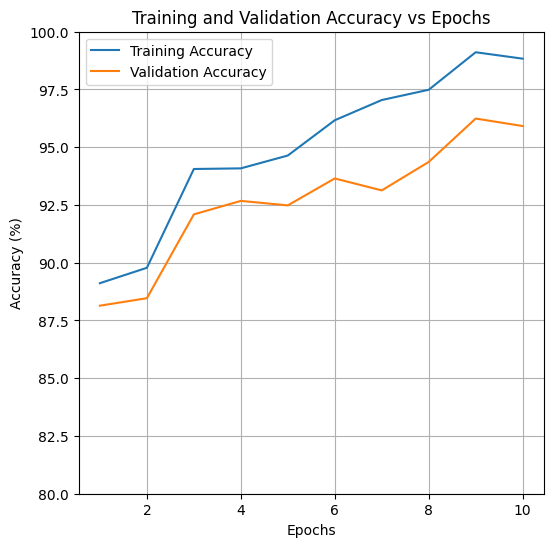

In [23]:
# plotting training and validation accuracy vs epochs
plt.figure(figsize=(6, 6))
plt.plot(range(1, epochs+1), train_accs, label='Training Accuracy')
plt.plot(range(1, epochs+1), val_accs, label='Validation Accuracy')
plt.title('Training and Validation Accuracy vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.ylim(80, 100)
plt.legend()
plt.grid(True)
plt.show()

**Evaluating the model**

In [18]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score

def evaluate(loader, model, device, class_names=None):
    model.eval()
    all_preds = []
    all_labels = []
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # accuracy
    acc = (correct/total) * 100
    print(f"Accuracy: {acc:.2f}%")

    # confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()

    # accuracy using sklearn
    overall_acc = accuracy_score(all_labels, all_preds) * 100
    print(f"Accuracy using sklearn: {overall_acc:.2f}\n")
    return acc, cm


Accuracy: 96.18%


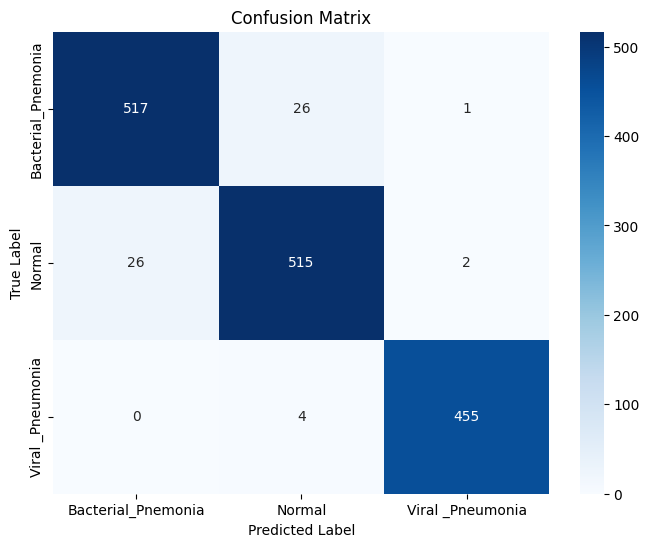

Accuracy using sklearn: 96.18



In [19]:
# loading best model
pneunomia_model = CNN()
pneunomia_model.load_state_dict(torch.load('/content/best_pneumonia_cnn.pth'))
pneunomia_model.to(device)

# evaluating on test dataset
acc, cm = evaluate(test_loader, pneunomia_model, device, class_names=test_dataset.classes)


Predictive System

In [27]:
from PIL import Image
import torch.nn.functional as F

# predicts the class of a single image and show confidence.
def predict_image(model, image_path, device, class_names, transform):

    model.eval()

    image = Image.open(image_path).convert('RGB')
    img_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img_tensor)
        probs = F.softmax(outputs, dim=1)
        confidence, predicted_class = torch.max(probs, 1)

    predicted_label = class_names[predicted_class.item()]
    confidence_value = confidence.item() * 100

    # displaying image
    plt.imshow(image)
    plt.title(f"Predicted: {predicted_label}, Confidence:({confidence_value:.2f}% )")
    plt.axis('off')
    plt.show()

    return predicted_label, confidence_value


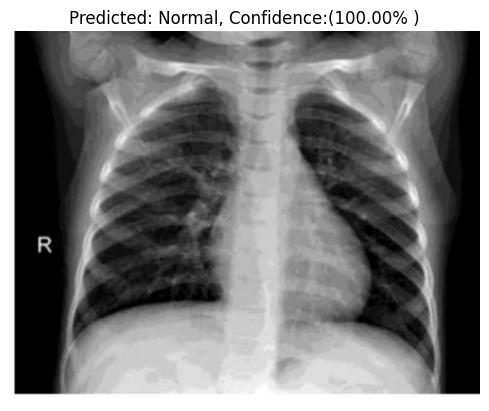

('Normal', 100.0)

In [29]:
# # prediction
image_path = "/content/normal.png"

predict_image(
    model=pneunomia_model,
    image_path=image_path,
    device=device,
    class_names=test_dataset.classes,
    transform=test_transforms
)